In [ ]:
from __future__ import annotations

import os
import sys
import warnings


project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from quant_pml.config.trading_config import TradingConfig
from deep_momentum.config.project_experiment_config import ProjectExperimentConfig
from deep_momentum.config.project_trading_config import ProjectTradingConfig
from quant_pml.hedge.market_futures_hedge import MarketFuturesHedge
from quant_pml.runner import build_backtest

%load_ext autoreload
%autoreload 2

QUANTILE = 0.1
REBAL_FREQ = "ME"

hedger = MarketFuturesHedge()

preprocessor, runner = build_backtest(
    experiment_config=ProjectExperimentConfig(),
    trading_config=ProjectTradingConfig(),
    rebal_freq=REBAL_FREQ,
)

Backtest on 2010-02-01 00:00:00 to 2024-12-31 00:00:00
Num Train Iterations: 179
Num Hedge Iterations: 3773
Num OOS Daily Points: 3755
Avg Num Stocks in Universe: 2533.43


Starting backtest with Logistic Regression Classifier...


Computing Weights:   0%|          | 0/179 [00:00<?, ?it/s]/Users/tdavi/Desktop/Se/ml studying/deep-momentum/deep_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
Computing Weights:   1%|          | 1/179 [00:00<02:40,  1.11it/s]/Users/tdavi/Desktop/Se/ml studying/deep-momentum/deep_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warni

                    value
metric                   
sharpe           0.116610
alpha_benchmark -0.014289
ir_benchmark    -0.173281


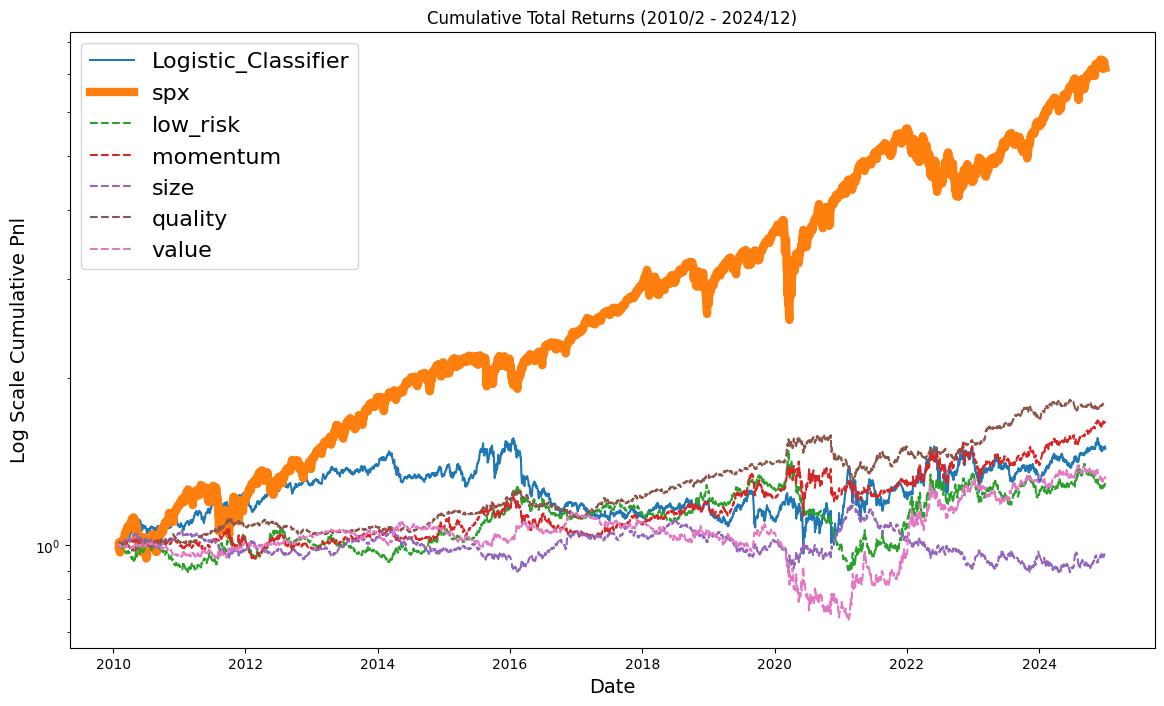

In [3]:
from deep_momentum.strategies.logistic_momentum import LogisticMomentum

print("Starting backtest with Logistic Regression Classifier...")
strategy_logistic = LogisticMomentum(
    quantile=QUANTILE,
    mode="long_short",
    C=1.0 # Сила регуляризации (можно потом потюнить)
)

res_logistic = runner(
    feature_processor=preprocessor,
    strategy=strategy_logistic,
    hedger=hedger,
)

print(res_logistic.to_pandas().loc[["sharpe", "alpha_benchmark", "ir_benchmark"]])
runner.plot_cumulative(strategy_name="Logistic_Classifier", include_factors=True)

In [4]:
from deep_momentum.strategies.mlp_classifier import MLPClassifierMomentum

print("Starting backtest with MLP Classifier (6 features)...")
strategy_mlp = MLPClassifierMomentum(
    quantile=QUANTILE,
    mode="long_short",
    hidden=64,
    dropout=0.3,
    epochs_first=10,  # Учим 10 эпох первый раз
    epochs_update=2   # Дообучаем 2 эпохи каждый месяц
)

res_mlp = runner(
    feature_processor=preprocessor,
    strategy=strategy_mlp,
    hedger=hedger,
)

print(res_mlp.to_pandas().loc[["sharpe", "alpha_benchmark", "ir_benchmark"]])
runner.plot_cumulative(strategy_name="MLP_Classifier", include_factors=True)

ModuleNotFoundError: No module named 'deep_momentum.strategies.mlp_classifier'